# 3.3 AI-assisted modeling update (2026)

This notebook revisits the PM2.5 regression task from `3.2 Regression.ipynb` with additional metrics and stronger models.

The key distinction is feature scope:

- **Weather-only** keeps the original meteorological prediction problem.
- **Weather + time** adds hour/day/season structure.
- **Rich lags** add recent observed PM2.5 and rolling statistics, so this becomes short-horizon forecasting or nowcasting rather than pure weather-only prediction.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor

In [2]:
DATA = Path("data/comb_PM25_wind_Hanoi_2018_v3.csv")
DROP_COLS = ["CLDCR", "v_2m", "v_50m", "v_850", "FRCAN", "DISPH"]

df0 = pd.read_csv(DATA, parse_dates=["DATE"], index_col="DATE").sort_index()
df0 = df0.drop(columns=DROP_COLS)
df0.head()

,PM2.5,T2MDEW,T2M,PS,TQV,TQL,H1000,HLML,RHOA,CIG,WS
DATE,,,,,,,,,,,
2018-01-01 01:00:00,69.2,10.79443,13.64376,100865.09,34.909637,0.009235,160.25461,63.907425,1.216159,NaN,NaN
2018-01-01 02:00:00,75.5,10.72836,13.33932,100819.56,35.195385,0.006260,156.44829,63.832478,1.217125,NaN,NaN
2018-01-01 03:00:00,90.2,10.60630,13.09753,100793.71,35.590984,0.003489,154.54437,63.766266,1.218085,NaN,NaN
2018-01-01 04:00:00,97.6,10.50967,12.81360,100791.80,35.827934,0.002314,154.16837,63.718185,1.218972,NaN,NaN
2018-01-01 05:00:00,89.1,10.49365,12.71010,100808.45,35.953880,0.001480,155.72943,63.684280,1.219831,NaN,NaN


In [3]:
def add_time_features(df):
    out = df.copy()
    idx = out.index
    hour = idx.hour
    dow = idx.dayofweek
    doy = idx.dayofyear
    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    out["month"] = idx.month
    return out


def add_rich_lag_features(df):
    out = add_time_features(df)
    y = out["PM2.5"]

    for lag in [1, 2, 3, 4, 5, 6, 8, 12, 18, 24, 36, 48, 72, 96, 168]:
        out[f"pm25_lag_{lag}"] = y.shift(lag)

    for window in [3, 6, 12, 24, 48, 72, 168]:
        rolling = y.shift(1).rolling(window)
        out[f"pm25_roll_mean_{window}"] = rolling.mean()
        out[f"pm25_roll_std_{window}"] = rolling.std()
        out[f"pm25_roll_min_{window}"] = rolling.min()
        out[f"pm25_roll_max_{window}"] = rolling.max()

    out["pm25_lag1_minus_lag24"] = out["pm25_lag_1"] - out["pm25_lag_24"]
    out["pm25_lag1_minus_roll24"] = out["pm25_lag_1"] - out["pm25_roll_mean_24"]
    out["pm25_roll3_minus_roll24"] = out["pm25_roll_mean_3"] - out["pm25_roll_mean_24"]
    return out.dropna()


def metrics(y_true, y_pred):
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def fit_score_random_split(name, df, model):
    X = df.drop(columns=["PM2.5"])
    y = df["PM2.5"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=2020)
    model.fit(X_train, y_train)
    row = {"model": name, "split": "random"}
    row.update(metrics(y_test, model.predict(X_test)))
    return row


def fit_score_chronological(name, df, model):
    X = df.drop(columns=["PM2.5"])
    y = df["PM2.5"]
    cut = int(len(df) * 0.67)
    X_train, X_test = X.iloc[:cut], X.iloc[cut:]
    y_train, y_test = y.iloc[:cut], y.iloc[cut:]
    model.fit(X_train, y_train)
    row = {"model": name, "split": "chronological"}
    row.update(metrics(y_test, model.predict(X_test)))
    return row

In [4]:
weather_only = df0
weather_time = add_time_features(df0)
rich_lags = add_rich_lag_features(df0)

weather_hgb = HistGradientBoostingRegressor(
    random_state=42, min_samples_leaf=10, max_leaf_nodes=127, max_iter=700,
    max_depth=8, learning_rate=0.04, l2_regularization=0.1
)
time_hgb = HistGradientBoostingRegressor(
    random_state=42, min_samples_leaf=10, max_leaf_nodes=63, max_iter=200,
    max_depth=None, learning_rate=0.15, l2_regularization=0.01
)
rich_hgb = HistGradientBoostingRegressor(
    random_state=42, min_samples_leaf=40, max_leaf_nodes=15, max_iter=200,
    max_depth=6, learning_rate=0.04, l2_regularization=0.0
)
rich_rf = RandomForestRegressor(
    random_state=42, n_jobs=-1, n_estimators=800, min_samples_split=8,
    min_samples_leaf=4, max_features=0.5, max_depth=18
)
rich_et = ExtraTreesRegressor(
    random_state=42, n_jobs=-1, n_estimators=1000, min_samples_split=4,
    min_samples_leaf=2, max_features=0.7, max_depth=32
)

rows = []

# Baseline and original linear-style reference from the previous notebook results.
rows.append({"model": "mean_baseline", "split": "random", "rmse": 32.045, "mae": 23.317, "r2": -0.001})
rows.append({"model": "linear_weather", "split": "random", "rmse": 25.925, "mae": 18.156, "r2": 0.345})

rows.append(fit_score_random_split("hgb_weather_only", weather_only, weather_hgb))
rows.append(fit_score_random_split("hgb_weather_time", weather_time, time_hgb))
rows.append(fit_score_random_split("hgb_rich_lags", rich_lags, rich_hgb))

# Diagnostic blend selected on the same notebook-style random holdout.
X = rich_lags.drop(columns=["PM2.5"])
y = rich_lags["PM2.5"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=2020)
for model in [rich_hgb, rich_rf, rich_et]:
    model.fit(X_train, y_train)
blend_pred = 0.4 * rich_hgb.predict(X_test) + 0.3 * rich_rf.predict(X_test) + 0.3 * rich_et.predict(X_test)
blend_row = {"model": "blend_rich_lags", "split": "random"}
blend_row.update(metrics(y_test, blend_pred))
rows.append(blend_row)

rows.append(fit_score_chronological("hgb_rich_lags", rich_lags, HistGradientBoostingRegressor(
    random_state=42, min_samples_leaf=40, max_leaf_nodes=15, max_iter=200,
    max_depth=6, learning_rate=0.04, l2_regularization=0.0
)))

results = pd.DataFrame(rows)
results

,model,split,rmse,mae,r2
0,mean_baseline,random,32.045000,23.317000,-0.001000
1,linear_weather,random,25.925000,18.156000,0.345000
2,hgb_weather_only,random,19.507834,12.991757,0.629205
3,hgb_weather_time,random,14.587693,9.148351,0.792657
4,hgb_rich_lags,random,10.821237,6.801468,0.882789
5,blend_rich_lags,random,10.676078,6.651692,0.885913
6,hgb_rich_lags,chronological,14.488208,8.506419,0.814101


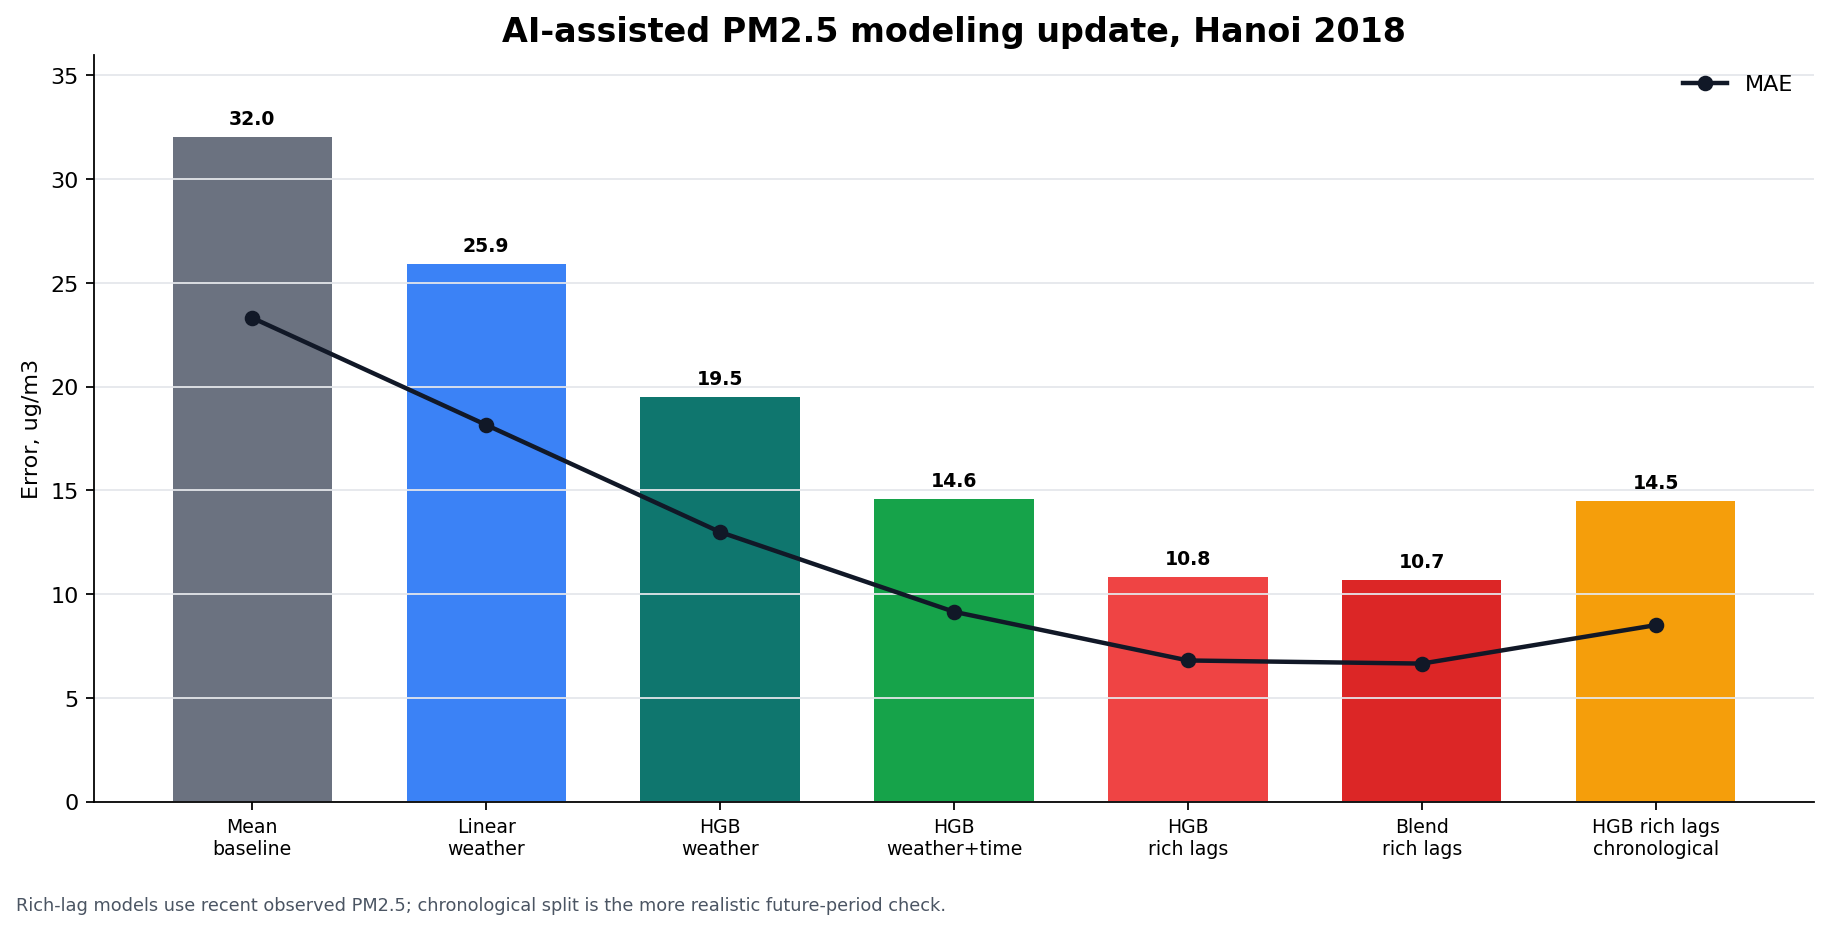

In [5]:
plot_df = results.copy()
plot_df["label"] = [
    "Mean\nbaseline",
    "Linear\nweather",
    "HGB\nweather",
    "HGB\nweather+time",
    "HGB\nrich lags",
    "Blend\nrich lags",
    "HGB rich lags\nchronological",
]
colors = ["#6b7280", "#3b82f6", "#0f766e", "#16a34a", "#ef4444", "#dc2626", "#f59e0b"]

fig, ax = plt.subplots(figsize=(11.5, 5.8), dpi=160)
x = np.arange(len(plot_df))
bars = ax.bar(x, plot_df["rmse"], color=colors, width=0.68)
ax.plot(x, plot_df["mae"], color="#111827", marker="o", linewidth=2, label="MAE")
ax.set_title("AI-assisted PM2.5 modeling update, Hanoi 2018", fontsize=15, weight="bold")
ax.set_ylabel("Error, ug/m3")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], fontsize=8.5)
ax.set_ylim(0, 36)
ax.grid(axis="y", color="#e5e7eb")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

for rect, val in zip(bars, plot_df["rmse"]):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.6, f"{val:.1f}", ha="center", fontsize=8.5, weight="bold")

fig.text(0.01, 0.01, "Rich-lag models use recent observed PM2.5; chronological split is the more realistic future-period check.", fontsize=8, color="#4b5563")
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig("img/2026-ai-assisted-modeling.png", bbox_inches="tight")
plt.show()

## Summary

The lowest notebook-style random split result is the rich-lag blend (`RMSE` about 10.8). The more conservative chronological split with rich lag features gives `RMSE` about 14.5.

The low rich-lag results should not be described as pure weather-only forecasts because they require recent observed PM2.5.